# 1. Mount Drive & Extract Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import zipfile for extraction
import zipfile

# Set the path to your new zip file in Google Drive
zip_path = "/content/drive/MyDrive/UTSW-Glioma.zip"

# Set extraction folder
extract_path = "/content/UTSW-Glioma"

# Extract the zip file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("UTSWGlioma extracted successfully")

UTSWGlioma extracted successfully


# Load Patient List

In [3]:
import os
base_path = os.path.join(extract_path, "UTSW-Glioma")  # adjust if needed

patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT1143', 'BT0144', 'BT1019', 'BT0252', 'BT0965']


# Visualize MRI Slices

Showing images for: BT1143
Shape: (240, 240, 155)


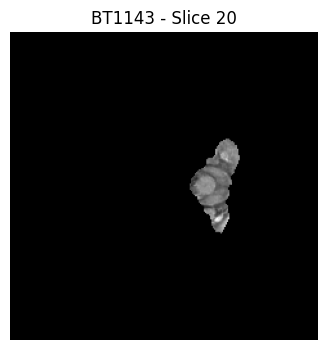

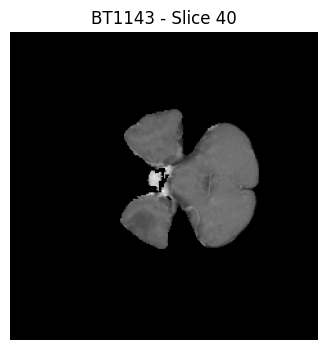

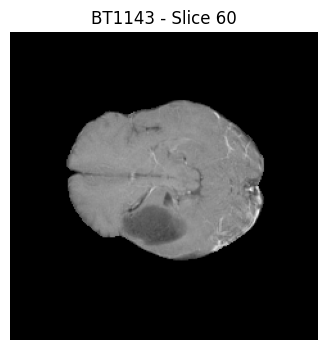

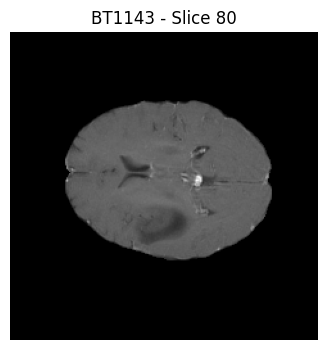

In [4]:
import nibabel as nib
import matplotlib.pyplot as plt

# Pick first patient
sample_patient = patients[0]
patient_path = os.path.join(base_path, sample_patient)

print("Showing images for:", sample_patient)

# Choose one modality (you can change this)
mri_path = os.path.join(patient_path, "brain_t1ce.nii.gz")

# Load MRI
img = nib.load(mri_path)
data = img.get_fdata()

print("Shape:", data.shape)

# Show multiple slices
slice_indices = [20, 40, 60, 80]

for i in slice_indices:
    if i < data.shape[2]:
        plt.figure(figsize=(4,4))
        plt.imshow(data[:, :, i], cmap="gray")
        plt.title(f"{sample_patient} - Slice {i}")
        plt.axis("off")
        plt.show()

# Verify Folder Structure

In [5]:
import os

extract_path = "/content/UTSW-Glioma"

print("Level 1:", os.listdir(extract_path))

Level 1: ['UTSW-Glioma']


In [6]:
inner = os.listdir(extract_path)[0]
print("Level 2:", os.listdir(os.path.join(extract_path, inner)))

Level 2: ['BT1143', 'BT0144', 'BT1019', 'BT0252', 'BT0965', 'BT0078', 'BT1011', 'BT0091', 'BT0907', 'BT0782', 'BT1229', 'BT0127', 'BT1311', 'BT0828', 'BT0436', 'BT0307', 'BT1114', 'BT0084', 'BT1301', 'BT0002', 'BT1028', 'BT1250', 'BT0338', 'BT0089', 'BT0204', 'BT0766', 'BT0600', 'BT1285', 'BT1213', 'BT0211', 'BT0405', 'BT0769', 'BT0033', 'BT1246', 'BT0416', 'BT1298', 'BT0258', 'BT0282', 'BT0488', 'BT0244', 'BT0448', 'BT0188', 'BT0958', 'BT0197', 'BT0802', 'BT0787', 'BT0900', 'BT0269', 'BT0972', 'BT0079', 'BT0489', 'BT0227', 'BT0732', 'BT0007', 'BT0649', 'BT0261', 'BT1073', 'BT0687', 'BT0686', 'BT0835', 'BT0280', 'BT0675', 'BT0639', 'BT0288', 'BT0399', 'BT0336', 'BT0210', 'BT0394', 'BT0398', 'BT1117', 'BT0704', 'BT0300', 'BT1122', 'BT0119', 'BT0719', 'BT0205', 'BT0368', 'BT0515', 'BT1296', 'BT0676', 'BT0063', 'BT0912', 'BT1039', 'BT1026', 'BT0001', 'BT0136', 'BT0376', 'BT0632', 'BT1273', 'BT0184', 'BT0622', 'BT0126', 'BT0090', 'BT1060', 'BT0020', 'BT0133', 'BT1123', 'BT0843', 'BT0036', 

# 5. Reload Patients

In [7]:
import os

extract_path = "/content/UTSW-Glioma"

# Correct base path
base_path = os.path.join(extract_path, "UTSW-Glioma")

# Load patients
patients = [
    p for p in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, p))
]

print("Total patients:", len(patients))
print("Sample patients:", patients[:5])

Total patients: 625
Sample patients: ['BT1143', 'BT0144', 'BT1019', 'BT0252', 'BT0965']


# 6. Feature Extraction Function

In [8]:
import numpy as np

def extract_features(image, mask=None, sample_size=5000):

    # Tumor region
    if mask is not None and np.sum(mask) > 0:
        pixels = image[mask > 0]

    # Non-tumor region (random sampling)
    else:
        flat = image.flatten()
        idx = np.random.choice(len(flat), min(sample_size, len(flat)), replace=False)
        pixels = flat[idx]

    # Safety check
    if len(pixels) == 0:
        return None

    # Feature extraction
    features = {
        "mean": float(np.mean(pixels)),
        "std": float(np.std(pixels)),
        "max": float(np.max(pixels)),
        "min": float(np.min(pixels)),
        "median": float(np.median(pixels)),
        "range": float(np.max(pixels) - np.min(pixels))
    }

    return features

# Dataset Creation (Multi-Modal) Create DataFrame & Clean Features


In [9]:
# ===============================
# IMPORTS (IMPORTANT)
# ===============================
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nibabel.processing import resample_from_to

# ===============================
# DATA STORAGE
# ===============================
data_list = []

# ===============================
# MULTI-MODAL FILES
# ===============================
modalities = {
    "t1": "brain_t1.nii.gz",
    "t1ce": "brain_t1ce.nii.gz",
    "t2": "brain_t2.nii.gz",
    "flair": "brain_flair.nii.gz"
}

# ===============================
# MAIN LOOP
# ===============================
for patient in patients:
    patient_path = os.path.join(base_path, patient)

    mask_path = os.path.join(patient_path, "tumorseg_manual_correction.nii.gz")

    if not os.path.exists(mask_path):
        continue

    try:
        # ------------------------------
        # LOAD MASK
        # ------------------------------
        mask_img = nib.load(mask_path)

        mri_data_all = {}
        ref_img = None

        # ------------------------------
        # LOAD ALL MRI MODALITIES
        # ------------------------------
        for key, file in modalities.items():
            path = os.path.join(patient_path, file)

            if os.path.exists(path):
                img = nib.load(path)
                mri_data_all[key] = img.get_fdata()

                if ref_img is None:
                    ref_img = img

        # Skip if no MRI
        if len(mri_data_all) == 0:
            continue

        # ------------------------------
        # RESAMPLE MASK
        # ------------------------------
        mask_resampled = resample_from_to(mask_img, ref_img, order=0)
        mask_data = mask_resampled.get_fdata()

        # ------------------------------
        # SAFE SLICE COUNT
        # ------------------------------
        num_slices = mask_data.shape[2]

        tumor_areas = np.array([
            mask_data[:, :, i].sum() for i in range(num_slices)
        ])

        # ==============================
        # TUMOR SAMPLES (label = 1)
        # ==============================
        tumor_slices = np.where(tumor_areas > 0)[0]

        for s in tumor_slices[:3]:

            feats = {}

            for mod, img in mri_data_all.items():

                # Safety check (IMPORTANT)
                if s >= img.shape[2]:
                    continue

                slice_img = img[:, :, s]

                f = extract_features(slice_img, mask_data[:, :, s])

                if f is not None:
                    for k, v in f.items():
                        feats[f"{mod}_{k}"] = v

            # Append only if features exist
            if len(feats) > 0:
                feats["label"] = 1
                feats["patient"] = patient
                data_list.append(feats)

        # ==============================
        # NON-TUMOR SAMPLES (label = 0)
        # ==============================
        non_tumor_slices = np.where(tumor_areas == 0)[0]

        if len(non_tumor_slices) > 0:

            step = max(1, len(non_tumor_slices)//3)

            for s in non_tumor_slices[::step][:3]:

                feats = {}

                for mod, img in mri_data_all.items():

                    # Safety check
                    if s >= img.shape[2]:
                        continue

                    slice_img = img[:, :, s]

                    f = extract_features(slice_img, None)

                    if f is not None:
                        for k, v in f.items():
                            feats[f"{mod}_{k}"] = v

                if len(feats) > 0:
                    feats["label"] = 0
                    feats["patient"] = patient
                    data_list.append(feats)

    except Exception as e:
        print(f"Skipping {patient}: {e}")

# ===============================
# CREATE DATAFRAME
# ===============================
df = pd.DataFrame(data_list)

print("Before cleaning:", df.shape)

# -------------------------------
# REMOVE ZERO FEATURE ROWS
# -------------------------------
feature_cols = [col for col in df.columns if col not in ["label", "patient"]]

df = df[(df[feature_cols] != 0).any(axis=1)]

print("After cleaning:", df.shape)

# -------------------------------
# CHECK DISTRIBUTION AGAIN
# -------------------------------
print("\nLabel distribution:\n", df["label"].value_counts())
print("\nSample data:\n", df.head())

Before cleaning: (2136, 26)
After cleaning: (2046, 26)

Label distribution:
 label
1    1037
0    1009
Name: count, dtype: int64

Sample data:
       t1_mean      t1_std       t1_max      t1_min   t1_median     t1_range  \
0  756.713788   35.266257   825.325684  646.897156  763.312134   178.428528   
1  755.064845   39.946895   831.899048  643.065308  762.826599   188.833740   
2  753.629541   41.847756   835.614746  635.027649  763.759033   200.587097   
4   52.387714  177.168786   825.614258    0.000000    0.000000   825.614258   
5  138.952156  265.487407  1007.718811    0.000000    0.000000  1007.718811   

    t1ce_mean    t1ce_std     t1ce_max    t1ce_min  ...   t2_median  \
0  775.558975   28.998500   833.619751  676.057312  ...  603.625183   
1  781.346706   28.836013   851.995483  689.426880  ...  605.360168   
2  783.131016   25.054728   869.012817  715.425354  ...  605.525574   
4   57.757286  196.254179  1292.459595    0.000000  ...    0.000000   
5  150.922354  282.347138 

In [10]:
# Remove rows with too many zero values (optional but recommended)
feature_cols = [c for c in df.columns if c not in ["label", "patient"]]

zero_fraction = (df[feature_cols] == 0).sum(axis=1) / len(feature_cols)

# Keep rows where less than 50% features are zero
df = df[zero_fraction < 0.5]

print("After zero-filter:", df.shape)
print(df["label"].value_counts())

After zero-filter: (2028, 26)
label
1    1037
0     991
Name: count, dtype: int64


# Data Cleaning

In [11]:
# ==========================================
# 5(a). DATA CLEANING
# ==========================================

print("Dataset Shape:", df.shape)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Summary statistics
print("\nStatistical Summary:\n", df.describe())

# Check zero-value rows
zero_rows = (df == 0).sum().sum()
print("\nTotal Zero Values:", zero_rows)

Dataset Shape: (2028, 26)

Missing Values:
 t1_mean         0
t1_std          0
t1_max          0
t1_min          0
t1_median       0
t1_range        0
t1ce_mean       0
t1ce_std        0
t1ce_max        0
t1ce_min        0
t1ce_median     0
t1ce_range      0
t2_mean         0
t2_std          0
t2_max          0
t2_min          0
t2_median       0
t2_range        0
flair_mean      0
flair_std       0
flair_max       0
flair_min       0
flair_median    0
flair_range     0
label           0
patient         0
dtype: int64

Duplicate Rows: 0

Statistical Summary:
              t1_mean         t1_std         t1_max         t1_min  \
count    2028.000000    2028.000000    2028.000000    2028.000000   
mean     2425.550412     681.687045    5476.192675    1825.137404   
std     19522.105133    5453.121428   36229.872258   16403.801570   
min         0.055708       0.000000     119.435875       0.000000   
25%        47.777077      21.353641     409.654129       0.000000   
50%       265.50564

# Exploratory Data Analysis (EDA)

# Class Distribution

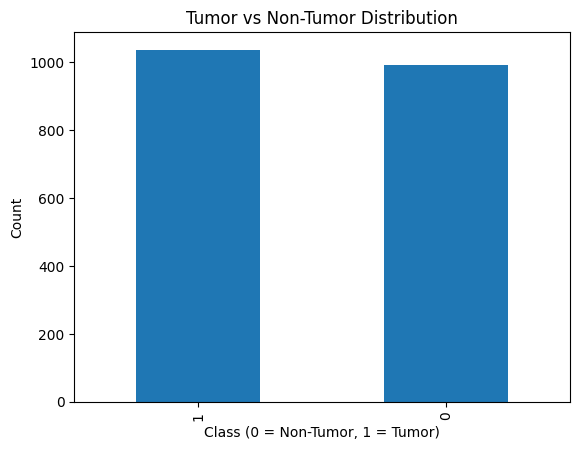

In [12]:
# ==========================================
# 5(b). EDA - CLASS DISTRIBUTION
# ==========================================

import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.title("Tumor vs Non-Tumor Distribution")
plt.xlabel("Class (0 = Non-Tumor, 1 = Tumor)")
plt.ylabel("Count")
plt.show()

# Feature Distribution

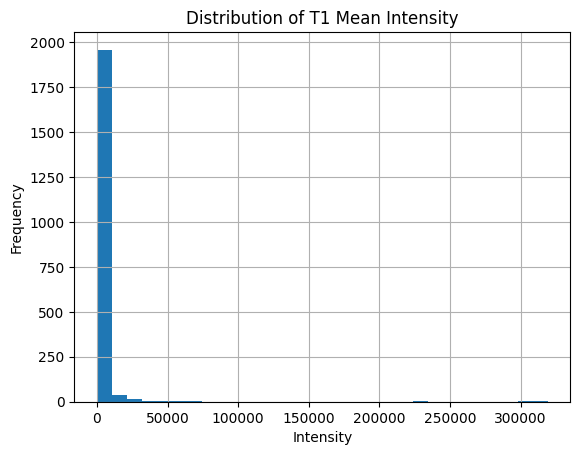

In [13]:
# ==========================================
# 5(b). EDA - FEATURE DISTRIBUTION
# ==========================================

df["t1_mean"].hist(bins=30)
plt.title("Distribution of T1 Mean Intensity")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap

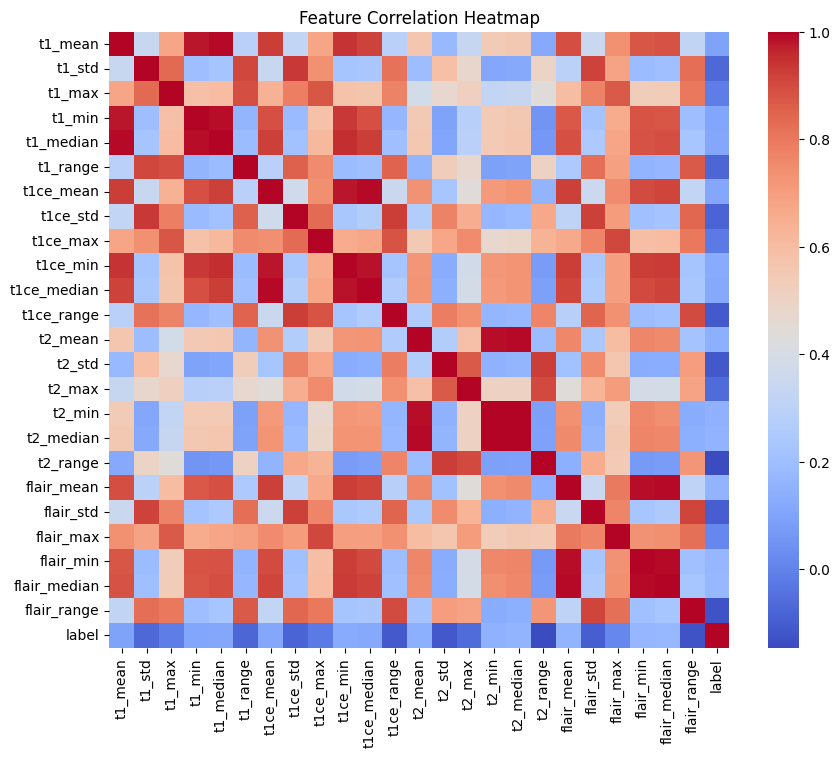

In [15]:
# ==========================================
# 5(b). EDA - CORRELATION HEATMAP (FIXED)
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

# Patient-Wise Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

# Get unique patients with their labels
patient_labels = df.groupby("patient")["label"].max().reset_index()

train_p, test_p = train_test_split(
    patient_labels["patient"],
    test_size=0.3,
    random_state=42,
    stratify=patient_labels["label"]  # 🔥 important
)

# Split dataset
train_df = df[df["patient"].isin(train_p)]
test_df = df[df["patient"].isin(test_p)]

# Features & target
X_train = train_df.drop(["label", "patient"], axis=1)
y_train = train_df["label"]

X_test = test_df.drop(["label", "patient"], axis=1)
y_test = test_df["label"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:\n", y_train.value_counts())
print("\nTest label distribution:\n", y_test.value_counts())

Train shape: (1410, 24)
Test shape: (618, 24)

Train label distribution:
 label
1    722
0    688
Name: count, dtype: int64

Test label distribution:
 label
1    315
0    303
Name: count, dtype: int64


# Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# XGBoost Model Training

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization
    random_state=42,
    eval_metric="logloss"
)

# Train with validation (early stopping)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

# XGBoost Evaluation

In [19]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9935275080906149

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       303
           1       1.00      0.99      0.99       315

    accuracy                           0.99       618
   macro avg       0.99      0.99      0.99       618
weighted avg       0.99      0.99      0.99       618



# GroupKFold Validation

In [20]:
from sklearn.model_selection import GroupKFold
import numpy as np

gkf = GroupKFold(n_splits=5)
scores = []

X = df.drop(columns=["label","patient"])
y = df["label"]
groups = df["patient"]

for tr, va in gkf.split(X, y, groups):
    Xtr, Xva = X.iloc[tr], X.iloc[va]
    ytr, yva = y.iloc[tr], y.iloc[va]

    Xtr = scaler.fit_transform(Xtr)
    Xva = scaler.transform(Xva)

    m = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    m.fit(Xtr, ytr)
    scores.append(m.score(Xva, yva))

print("GroupKFold Accuracy:", np.mean(scores))

GroupKFold Accuracy: 0.9926108075533362


# Confusion Matrix

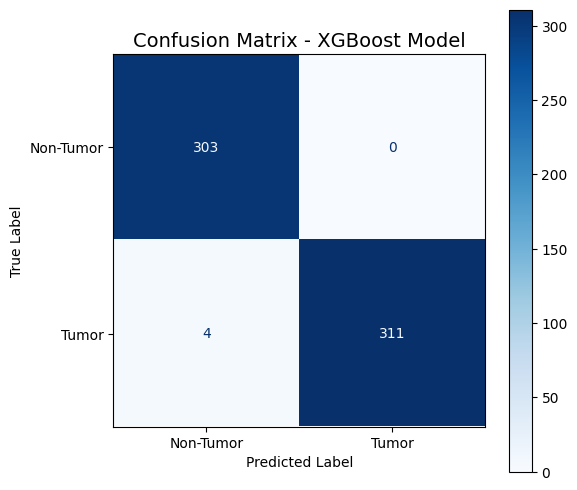

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display with labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Tumor", "Tumor"]
)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=True)

plt.title("Confusion Matrix - XGBoost Model", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.grid(False)
plt.show()

# ROC Curve

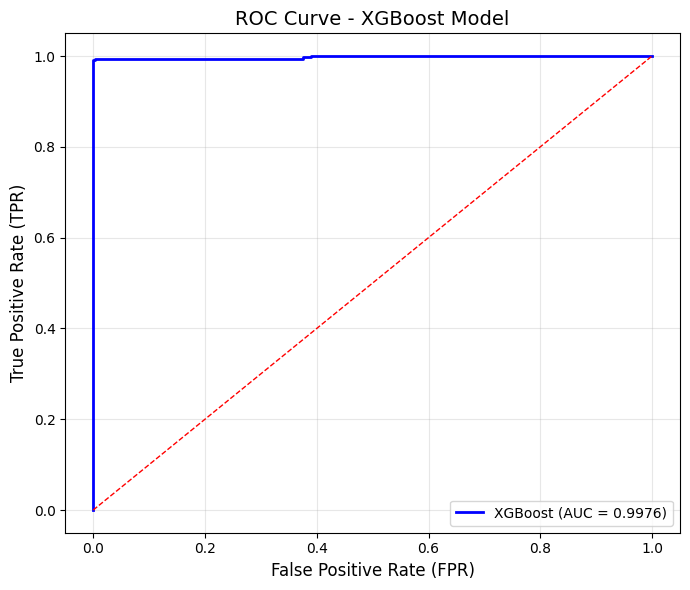

ROC-AUC Score: 0.9975588034993976


In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f"XGBoost (AUC = {roc_auc:.4f})")

# Diagonal line (random model)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1)

# Labels & title
plt.xlabel("False Positive Rate (FPR)", fontsize=12)
plt.ylabel("True Positive Rate (TPR)", fontsize=12)
plt.title("ROC Curve - XGBoost Model", fontsize=14)

# Legend
plt.legend(loc="lower right")

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print AUC
print("ROC-AUC Score:", roc_auc)

# Feature Importance

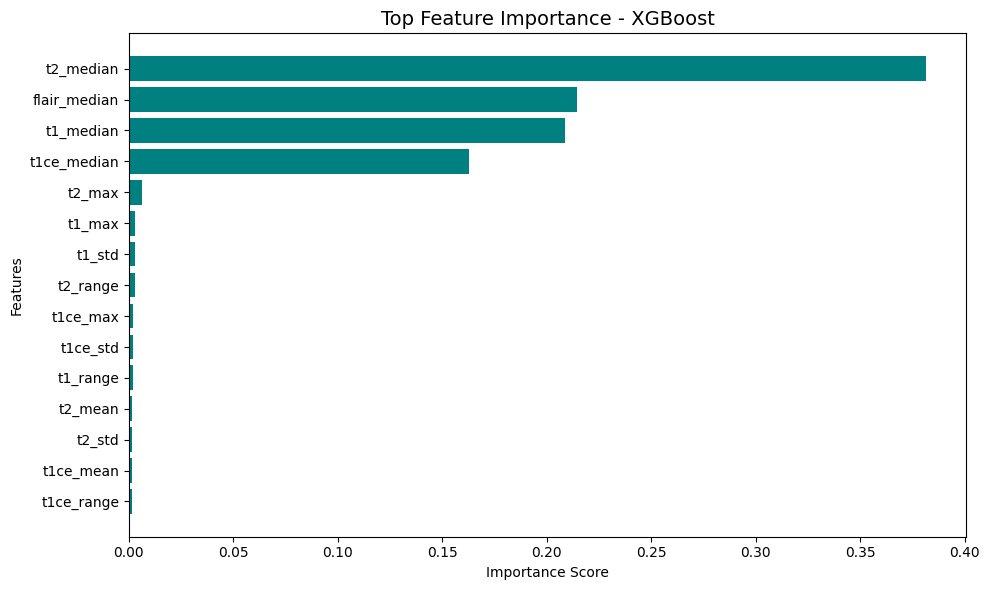

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature names from dataframe
feature_names = X.columns  # IMPORTANT

# Get importance values
importances = model.feature_importances_

# Create dataframe
feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features
feat_df = feat_df.sort_values(by="Importance", ascending=False)

# Select top 15 features (clean visualization)
top_n = 15
feat_df_top = feat_df.head(top_n)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df_top["Feature"], feat_df_top["Importance"], color="teal")
plt.gca().invert_yaxis()

plt.title("Top Feature Importance - XGBoost", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

# ML Model Comparison

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier
import pandas as pd

# ===============================
# MODELS (OPTIMIZED)
# ===============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        C=1.0
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

# ===============================
# TRAIN + EVALUATE
# ===============================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "ROC-AUC": auc
    })

    print(f"{name}: Accuracy = {acc:.4f}, AUC = {auc:.4f}")

# ===============================
# RESULT TABLE
# ===============================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print("\nFinal Comparison:\n")
print(results_df)

Logistic Regression: Accuracy = 0.9790, AUC = 0.9976
SVM: Accuracy = 0.9709, AUC = 0.9875
KNN: Accuracy = 0.9919, AUC = 0.9935
Random Forest: Accuracy = 0.9919, AUC = 0.9993
Gradient Boosting: Accuracy = 0.9935, AUC = 0.9975
XGBoost: Accuracy = 0.9935, AUC = 0.9973

Final Comparison:

                 Model  Accuracy   ROC-AUC
4    Gradient Boosting  0.993528  0.997527
5              XGBoost  0.993528  0.997328
3        Random Forest  0.991909  0.999314
2                  KNN  0.991909  0.993473
0  Logistic Regression  0.978964  0.997580
1                  SVM  0.970874  0.987516


# Final Model Comparison Table

In [25]:
import pandas as pd

# Convert results (list of dicts) to DataFrame
results_df = pd.DataFrame(results)

# Sort by Accuracy (or use ROC-AUC if needed)
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# Display nicely
print("\nFinal Model Comparison:\n")
print(results_df.to_string(index=False))


Final Model Comparison:

              Model  Accuracy  ROC-AUC
  Gradient Boosting  0.993528 0.997527
            XGBoost  0.993528 0.997328
      Random Forest  0.991909 0.999314
                KNN  0.991909 0.993473
Logistic Regression  0.978964 0.997580
                SVM  0.970874 0.987516


# Create Deep Learning Image Dataset

In [26]:
import os
import cv2
import nibabel as nib
import numpy as np
from nibabel.processing import resample_from_to

# ===============================
# OUTPUT FOLDERS
# ===============================
img_dir = "/content/dl_dataset"
os.makedirs(os.path.join(img_dir, "tumor"), exist_ok=True)
os.makedirs(os.path.join(img_dir, "non_tumor"), exist_ok=True)

saved_count = 0

# ===============================
# MAIN LOOP (INCREASE PATIENTS)
# ===============================
for patient in patients[:150]:  # 🔥 increased from 50 → 150
    p_path = os.path.join(base_path, patient)

    mri_path = os.path.join(p_path, "brain_t1ce.nii.gz")
    mask_path = os.path.join(p_path, "tumorseg_manual_correction.nii.gz")

    if not (os.path.exists(mri_path) and os.path.exists(mask_path)):
        continue

    try:
        # ------------------------------
        # LOAD MRI
        # ------------------------------
        mri_img = nib.load(mri_path)
        mri = mri_img.get_fdata()

        # ------------------------------
        # LOAD + RESAMPLE MASK
        # ------------------------------
        mask_img = nib.load(mask_path)
        mask_resampled = resample_from_to(mask_img, mri_img, order=0)
        mask = mask_resampled.get_fdata()

        num_slices = min(mri.shape[2], mask.shape[2])

        # ------------------------------
        # FIND TUMOR SLICES
        # ------------------------------
        tumor_areas = np.array([np.sum(mask[:, :, i]) for i in range(num_slices)])

        tumor_slices = np.where(tumor_areas > 0)[0]
        non_tumor_slices = np.where(tumor_areas == 0)[0]

        # ===============================
        # SAVE TUMOR IMAGES (MORE SAMPLES)
        # ===============================
        for i in tumor_slices[:10]:  # 🔥 increased from 5 → 10

            img = mri[:, :, i]

            if np.max(img) == 0:
                continue

            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
            img = cv2.resize(img, (224, 224))

            base_name = f"{patient}_{i}"

            # Save original
            cv2.imwrite(os.path.join(img_dir, "tumor", base_name + ".png"), img)

            # 🔥 Augmentation (flip)
            cv2.imwrite(os.path.join(img_dir, "tumor", base_name + "_flip.png"), cv2.flip(img, 1))

            saved_count += 2

        # ===============================
        # SAVE NON-TUMOR IMAGES (BALANCED)
        # ===============================
        step = max(1, len(non_tumor_slices)//10)

        for i in non_tumor_slices[::step][:10]:  # 🔥 increased

            img = mri[:, :, i]

            if np.max(img) == 0:
                continue

            img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype("uint8")
            img = cv2.resize(img, (224, 224))

            base_name = f"{patient}_{i}"

            # Save original
            cv2.imwrite(os.path.join(img_dir, "non_tumor", base_name + ".png"), img)

            # 🔥 Augmentation (flip)
            cv2.imwrite(os.path.join(img_dir, "non_tumor", base_name + "_flip.png"), cv2.flip(img, 1))

            saved_count += 2

    except Exception as e:
        print(f"Skipping {patient}: {e}")

print("Total images saved:", saved_count)

Total images saved: 3260


# Count Saved Images

In [27]:
print(len(os.listdir(img_dir + "/tumor")))
print(len(os.listdir(img_dir + "/non_tumor")))

1700
1560


# ResNet Training

In [28]:
# ===============================
# IMPORTS
# ===============================
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn, optim
from sklearn.metrics import accuracy_score

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ===============================
# TRANSFORMS (WITH AUGMENTATION)
# ===============================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),

    # 🔥 Augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# ===============================
# MODEL (TRANSFER LEARNING)
# ===============================
resnet = torchvision.models.resnet18(weights="IMAGENET1K_V1")

# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier
resnet.fc = nn.Linear(resnet.fc.in_features, 2)

resnet = resnet.to(device)

# ===============================
# LOSS & OPTIMIZER
# ===============================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    resnet.fc.parameters(),  # only last layer
    lr=0.0001
)

# ===============================
# TRAINING LOOP
# ===============================
epochs = 5

for epoch in range(epochs):
    resnet.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = resnet(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

# ===============================
# EVALUATION
# ===============================
resnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = resnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print("\nResNet Accuracy:", acc)

Using device: cuda
Total images: 3260
Classes: ['non_tumor', 'tumor']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Epoch 1/5, Loss: 51.1272
Epoch 2/5, Loss: 46.8096
Epoch 3/5, Loss: 45.5929
Epoch 4/5, Loss: 44.2222
Epoch 5/5, Loss: 43.1827

ResNet Accuracy: 0.7607361963190185


# EfficientNet Training

In [29]:
# ===============================
# IMPORTS
# ===============================
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torch import nn, optim
from sklearn.metrics import accuracy_score

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ===============================
# TRANSFORMS (WITH AUGMENTATION)
# ===============================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),

    # 🔥 Data Augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# ===============================
# MODEL (EFFICIENTNET-B0)
# ===============================
efficientnet = torchvision.models.efficientnet_b0(weights="IMAGENET1K_V1")

# Freeze backbone
for param in efficientnet.parameters():
    param.requires_grad = False

# Replace classifier
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, 2
)

efficientnet = efficientnet.to(device)

# ===============================
# LOSS & OPTIMIZER
# ===============================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    efficientnet.classifier.parameters(),  # only classifier
    lr=0.0001
)

# ===============================
# TRAINING LOOP
# ===============================
epochs = 5

for epoch in range(epochs):
    efficientnet.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss:.4f}")

# ===============================
# EVALUATION
# ===============================
efficientnet.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = efficientnet(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Accuracy
acc = accuracy_score(all_labels, all_preds)
print("\nEfficientNet Accuracy:", acc)

Using device: cuda
Total images: 3260
Classes: ['non_tumor', 'tumor']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


Epoch 1/5, Loss: 50.5704
Epoch 2/5, Loss: 45.9585
Epoch 3/5, Loss: 43.7632
Epoch 4/5, Loss: 43.0821
Epoch 5/5, Loss: 42.0272

EfficientNet Accuracy: 0.8067484662576687


# Deep Learning Evaluation Function

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, name="Model"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Metrics
    acc = accuracy_score(all_labels, all_preds)

    print(f"\n{name} Results:")
    print("Accuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    return acc

# Final DL Results

In [31]:
resnet_acc = evaluate_model(resnet, "ResNet")
effnet_acc = evaluate_model(efficientnet, "EfficientNet")

print("\nFinal DL Results:")
print("ResNet Accuracy:", resnet_acc)
print("EfficientNet Accuracy:", effnet_acc)


ResNet Results:
Accuracy: 0.754601226993865

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.68      0.72       306
           1       0.74      0.82      0.78       346

    accuracy                           0.75       652
   macro avg       0.76      0.75      0.75       652
weighted avg       0.76      0.75      0.75       652

Confusion Matrix:
[[209  97]
 [ 63 283]]

EfficientNet Results:
Accuracy: 0.8098159509202454

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       306
           1       0.78      0.89      0.83       346

    accuracy                           0.81       652
   macro avg       0.82      0.80      0.81       652
weighted avg       0.82      0.81      0.81       652

Confusion Matrix:
[[220  86]
 [ 38 308]]

Final DL Results:
ResNet Accuracy: 0.754601226993865
EfficientNet Accuracy: 0.8098159509202454


# Fixed Dataset Preparation

In [32]:
# ===============================
# IMPORTS
# ===============================
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# ===============================
# DEVICE
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ===============================
# TRANSFORMS (FIXED)
# ===============================
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),   # 🔥 important
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # 🔥 fixed
])

# ===============================
# DATASET
# ===============================
data_dir = "/content/dl_dataset"
dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

# ===============================
# TRAIN / TEST SPLIT
# ===============================
torch.manual_seed(42)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

# ===============================
# DATALOADERS
# ===============================
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))

Using device: cuda
Total images: 3260
Classes: ['non_tumor', 'tumor']
Train size: 2608
Test size: 652


# Load ResNet Model

In [33]:
import torchvision
from torch import nn

# ===============================
# LOAD PRETRAINED MODEL (UPDATED)
# ===============================
resnet = torchvision.models.resnet18(weights="IMAGENET1K_V1")

# ===============================
# FREEZE BACKBONE
# ===============================
for param in resnet.parameters():
    param.requires_grad = False

# ===============================
# REPLACE FINAL LAYER
# ===============================
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 2)

# ===============================
# SEND TO DEVICE
# ===============================
resnet = resnet.to(device)

print("ResNet model ready")

ResNet model ready


# Load EfficientNet Model

In [34]:
import torchvision
from torch import nn

# ===============================
# LOAD PRETRAINED MODEL (UPDATED)
# ===============================
efficientnet = torchvision.models.efficientnet_b0(weights="IMAGENET1K_V1")

# ===============================
# FREEZE BACKBONE
# ===============================
for param in efficientnet.parameters():
    param.requires_grad = False

# ===============================
# REPLACE CLASSIFIER
# ===============================
num_features = efficientnet.classifier[1].in_features

efficientnet.classifier[1] = nn.Linear(num_features, 2)

# ===============================
# SEND TO DEVICE
# ===============================
efficientnet = efficientnet.to(device)

print("EfficientNet model ready")

EfficientNet model ready


# Define Loss Function & Optimizers

In [35]:
from torch import optim
from torch import nn

# ===============================
# LOSS FUNCTION
# ===============================
criterion = nn.CrossEntropyLoss()

# ===============================
# RESNET OPTIMIZER
# ===============================
resnet_optimizer = optim.Adam(
    resnet.fc.parameters(),   # train only final layer
    lr=1e-4,                  # 🔥 reduced for stability
    weight_decay=1e-4         # 🔥 regularization
)

# ===============================
# EFFICIENTNET OPTIMIZER
# ===============================
eff_optimizer = optim.Adam(
    efficientnet.classifier.parameters(),  # train classifier only
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizers ready")

Optimizers ready


# Reusable Training Function

In [36]:
def train_model(model, optimizer, epochs=8, name="Model"):
    best_acc = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total

        print(f"{name} | Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc

    print(f"\nBest {name} Validation Accuracy: {best_acc:.4f}")

    return best_acc   # 🔥 THIS LINE FIXES YOUR ERROR

# Train ResNet & EfficientNet

In [37]:
print("="*50)
print("🚀 Training ResNet Model")
print("="*50)

resnet_acc = train_model(
    resnet,
    resnet_optimizer,
    epochs=8,
    name="ResNet"
)

print("\n" + "="*50)
print("🚀 Training EfficientNet Model")
print("="*50)

effnet_acc = train_model(
    efficientnet,
    eff_optimizer,
    epochs=8,
    name="EfficientNet"
)

print("\n" + "="*50)
print("🏁 FINAL DL RESULTS")
print("="*50)

print(f"ResNet Best Accuracy: {resnet_acc:.4f}")
print(f"EfficientNet Best Accuracy: {effnet_acc:.4f}")

🚀 Training ResNet Model
ResNet | Epoch 1/8 | Loss: 51.5332 | Train Acc: 0.6522 | Val Acc: 0.7132
ResNet | Epoch 2/8 | Loss: 47.8848 | Train Acc: 0.6986 | Val Acc: 0.7362
ResNet | Epoch 3/8 | Loss: 45.3849 | Train Acc: 0.7308 | Val Acc: 0.7393
ResNet | Epoch 4/8 | Loss: 44.4494 | Train Acc: 0.7381 | Val Acc: 0.7669
ResNet | Epoch 5/8 | Loss: 44.0159 | Train Acc: 0.7419 | Val Acc: 0.7791
ResNet | Epoch 6/8 | Loss: 42.5173 | Train Acc: 0.7623 | Val Acc: 0.7776
ResNet | Epoch 7/8 | Loss: 42.8702 | Train Acc: 0.7527 | Val Acc: 0.7807
ResNet | Epoch 8/8 | Loss: 41.8344 | Train Acc: 0.7561 | Val Acc: 0.7899

Best ResNet Validation Accuracy: 0.7899

🚀 Training EfficientNet Model
EfficientNet | Epoch 1/8 | Loss: 52.8777 | Train Acc: 0.6346 | Val Acc: 0.7408
EfficientNet | Epoch 2/8 | Loss: 47.2545 | Train Acc: 0.7285 | Val Acc: 0.7791
EfficientNet | Epoch 3/8 | Loss: 44.2519 | Train Acc: 0.7558 | Val Acc: 0.7761
EfficientNet | Epoch 4/8 | Loss: 42.8479 | Train Acc: 0.7646 | Val Acc: 0.8098
Effi

# T1 Only vs Multi-Modal Comparison

In [38]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

y = df["label"]

# ===============================
# SINGLE MODALITY (T1 ONLY)
# ===============================
t1_cols = [col for col in df.columns if col.startswith("t1_")]
X_t1 = df[t1_cols]

Xtr, Xte, ytr, yte = train_test_split(X_t1, y, test_size=0.3, random_state=42)

model_t1 = XGBClassifier(eval_metric='logloss')
model_t1.fit(Xtr, ytr)

pred_t1 = model_t1.predict(Xte)
acc_t1 = accuracy_score(yte, pred_t1)

# ===============================
# MULTI-MODAL (ALL FEATURES)
# ===============================
X_full = df.drop(["label", "patient"], axis=1)

Xtr, Xte, ytr, yte = train_test_split(X_full, y, test_size=0.3, random_state=42)

model_multi = XGBClassifier(eval_metric='logloss')
model_multi.fit(Xtr, ytr)

pred_multi = model_multi.predict(Xte)
acc_multi = accuracy_score(yte, pred_multi)

# ===============================
# RESULT
# ===============================
print("T1 Only Accuracy:", acc_t1)
print("Multi-Modal Accuracy:", acc_multi)

T1 Only Accuracy: 0.9950738916256158
Multi-Modal Accuracy: 0.9967159277504105


In [39]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop(["label", "patient"], axis=1)
y = df["label"]

selector = SelectKBest(score_func=f_classif, k=15)  # keep best features
X_selected = selector.fit_transform(X, y)

Xtr, Xte, ytr, yte = train_test_split(X_selected, y, test_size=0.3, random_state=42)

model = XGBClassifier(eval_metric='logloss')
model.fit(Xtr, ytr)

print("Selected Multi-modal Accuracy:", model.score(Xte, yte))

Selected Multi-modal Accuracy: 0.9967159277504105


In [40]:
# Example: T1CE + FLAIR only
cols = [c for c in df.columns if c.startswith("t1ce_") or c.startswith("flair_")]
X = df[cols]

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9
)

         Model  Accuracy
0      T1 Only  0.993432
1  Multi-Modal  0.996716


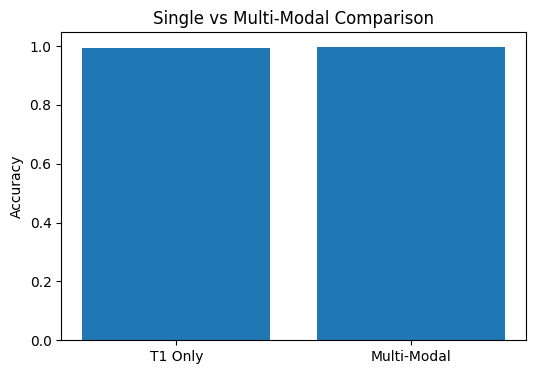

In [43]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

y = df["label"]

# ===============================
# CREATE SAME SPLIT
# ===============================
train_idx, test_idx = train_test_split(
    df.index, test_size=0.3, random_state=42, stratify=y
)

# ===============================
# SINGLE MODALITY (T1)
# ===============================
t1_cols = [col for col in df.columns if col.startswith("t1_")]

X_t1 = df.loc[:, t1_cols]

Xtr_t1 = X_t1.loc[train_idx]
Xte_t1 = X_t1.loc[test_idx]

ytr = y.loc[train_idx]
yte = y.loc[test_idx]

model_t1 = XGBClassifier(eval_metric='logloss')
model_t1.fit(Xtr_t1, ytr)

pred_t1 = model_t1.predict(Xte_t1)
acc_t1 = accuracy_score(yte, pred_t1)

# ===============================
# MULTI-MODAL (ALL FEATURES)
# ===============================
X_full = df.drop(["label", "patient"], axis=1)

Xtr_full = X_full.loc[train_idx]
Xte_full = X_full.loc[test_idx]

model_multi = XGBClassifier(eval_metric='logloss')
model_multi.fit(Xtr_full, ytr)

pred_multi = model_multi.predict(Xte_full)
acc_multi = accuracy_score(yte, pred_multi)

# ===============================
# RESULT TABLE
# ===============================
results = pd.DataFrame({
    "Model": ["T1 Only", "Multi-Modal"],
    "Accuracy": [acc_t1, acc_multi]
})

print(results)

# ===============================
# VISUAL COMPARISON
# ===============================
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Single vs Multi-Modal Comparison")
plt.ylabel("Accuracy")
plt.show()

# ML and DL Comparison Results

In [44]:
# ==========================================
# ML AND DL MODEL COMPARISON RESULTS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# ML RESULTS
# -------------------------------
ml_results = results_df.copy()
ml_results["Model Type"] = "Machine Learning"

# -------------------------------
# DL RESULTS
# -------------------------------
dl_results = pd.DataFrame({
    "Model": ["ResNet", "EfficientNet"],
    "Accuracy": [resnet_acc, effnet_acc],
    "ROC-AUC": [None, None],
    "Model Type": ["Deep Learning", "Deep Learning"]
})

# -------------------------------
# COMBINE ML + DL RESULTS
# -------------------------------
comparison_df = pd.concat([ml_results, dl_results], ignore_index=True)

# Sort by Accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

print("\nFinal ML vs DL Comparison:\n")
print(comparison_df.to_string(index=False))


Final ML vs DL Comparison:

              Model  Accuracy  ROC-AUC       Model Type
  Gradient Boosting  0.993528 0.997527 Machine Learning
            XGBoost  0.993528 0.997328 Machine Learning
      Random Forest  0.991909 0.999314 Machine Learning
                KNN  0.991909 0.993473 Machine Learning
Logistic Regression  0.978964 0.997580 Machine Learning
                SVM  0.970874 0.987516 Machine Learning
       EfficientNet  0.811350      NaN    Deep Learning
             ResNet  0.789877      NaN    Deep Learning


/tmp/ipykernel_245/3910503536.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat([ml_results, dl_results], ignore_index=True)


# ML vs DL Accuracy Bar Chart

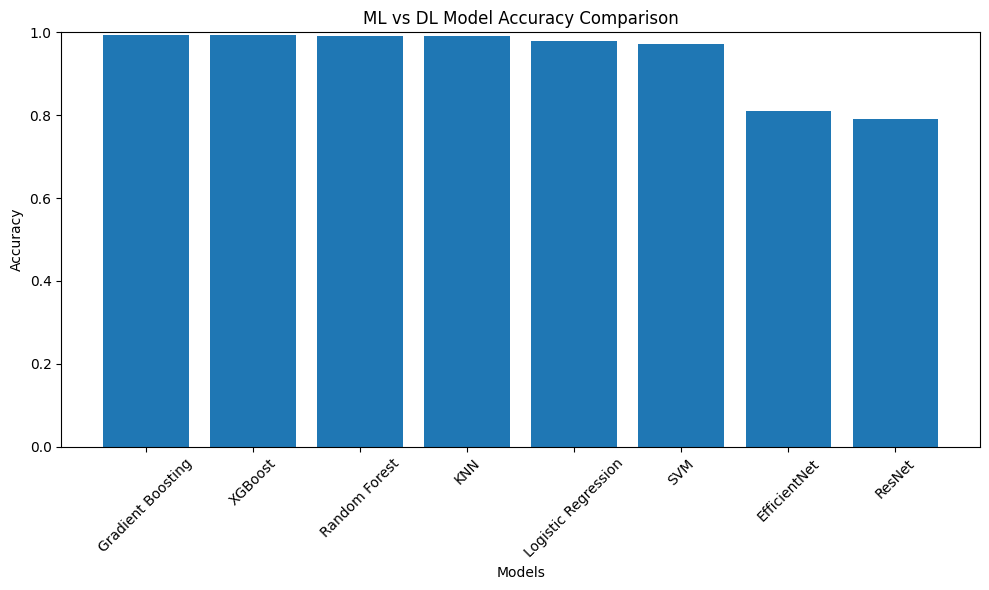

In [45]:
# ==========================================
# ML VS DL ACCURACY VISUALIZATION
# ==========================================

plt.figure(figsize=(10,6))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])

plt.title("ML vs DL Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Best Model Selection

In [46]:
# ==========================================
# BEST MODEL SELECTION
# ==========================================

best_model = comparison_df.iloc[0]

print("Best Performing Model:")
print("Model:", best_model["Model"])
print("Model Type:", best_model["Model Type"])
print("Accuracy:", best_model["Accuracy"])

Best Performing Model:
Model: Gradient Boosting
Model Type: Machine Learning
Accuracy: 0.9935275080906149


# Model Choice and Feature Engineering Justification

In [47]:
# ==========================================
# MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION
# ==========================================

print("="*70)
print("MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION")
print("="*70)

# -------------------------------
# FEATURES INCLUDED
# -------------------------------
feature_cols = [col for col in df.columns if col not in ["label", "patient"]]

print("\nFEATURES INCLUDED IN THE MODEL:")
print(feature_cols)

print("\nNumber of Features Used:", len(feature_cols))

# Group features by MRI modality
modalities_used = {}

for col in feature_cols:
    modality = col.split("_")[0]
    modalities_used.setdefault(modality, []).append(col)

print("\nFEATURES GROUPED BY MRI MODALITY:")
for modality, features in modalities_used.items():
    print(f"\n{modality.upper()} Features:")
    for f in features:
        print("-", f)

# -------------------------------
# FEATURE ENGINEERING DETAILS
# -------------------------------
print("\n" + "="*70)
print("FEATURE ENGINEERING PERFORMED")
print("="*70)

print("""
Feature engineering was performed by extracting statistical intensity-based
features from MRI image slices.

For each MRI modality, the following features were extracted:
1. Mean intensity
2. Standard deviation
3. Maximum intensity
4. Minimum intensity
5. Median intensity
6. Intensity range

These features were selected because tumor regions often show different
intensity patterns compared to normal brain tissue. Multi-modal MRI features
were used because each modality provides different anatomical or contrast
information useful for tumor detection.
""")

# -------------------------------
# MODEL CHOICE JUSTIFICATION
# -------------------------------
print("\n" + "="*70)
print("CHOICE OF MODELS WITH JUSTIFICATION")
print("="*70)

model_justification = {
    "Logistic Regression":
    "Used as a simple baseline linear classifier to compare against more complex models.",

    "SVM":
    "Used because it performs well on small-to-medium datasets and can model non-linear decision boundaries using the RBF kernel.",

    "KNN":
    "Used as a distance-based classifier to evaluate whether tumor and non-tumor samples form separable clusters in feature space.",

    "Random Forest":
    "Used because it handles non-linear relationships and reduces overfitting through ensemble decision trees.",

    "Gradient Boosting":
    "Used because boosting improves weak learners sequentially and captures complex feature interactions.",

    "XGBoost":
    "Used because it is an optimized gradient boosting algorithm with regularization, strong performance on tabular features, and robustness to feature interactions.",

    "ResNet18":
    "Used as a deep learning transfer learning model to learn visual patterns directly from MRI image slices.",

    "EfficientNet-B0":
    "Used because it is computationally efficient and balances model depth, width, and resolution for image classification."
}

for model, reason in model_justification.items():
    print(f"\n{model}:")
    print(reason)

# -------------------------------
# BASIS FOR DECISION
# -------------------------------
print("\n" + "="*70)
print("BASIS FOR FEATURE AND MODEL DECISION")
print("="*70)

print("""
The decision to use statistical features was based on the intensity differences
between tumor and non-tumor regions in MRI scans.

Traditional machine learning models were selected to evaluate performance on
hand-crafted features, while deep learning models were selected to evaluate
performance when image patterns are learned automatically.

Patient-wise splitting was used to reduce data leakage, ensuring that slices
from the same patient do not appear in both training and testing sets.
""")

MODEL CHOICE AND FEATURE ENGINEERING JUSTIFICATION

FEATURES INCLUDED IN THE MODEL:
['t1_mean', 't1_std', 't1_max', 't1_min', 't1_median', 't1_range', 't1ce_mean', 't1ce_std', 't1ce_max', 't1ce_min', 't1ce_median', 't1ce_range', 't2_mean', 't2_std', 't2_max', 't2_min', 't2_median', 't2_range', 'flair_mean', 'flair_std', 'flair_max', 'flair_min', 'flair_median', 'flair_range']

Number of Features Used: 24

FEATURES GROUPED BY MRI MODALITY:

T1 Features:
- t1_mean
- t1_std
- t1_max
- t1_min
- t1_median
- t1_range

T1CE Features:
- t1ce_mean
- t1ce_std
- t1ce_max
- t1ce_min
- t1ce_median
- t1ce_range

T2 Features:
- t2_mean
- t2_std
- t2_max
- t2_min
- t2_median
- t2_range

FLAIR Features:
- flair_mean
- flair_std
- flair_max
- flair_min
- flair_median
- flair_range

FEATURE ENGINEERING PERFORMED

Feature engineering was performed by extracting statistical intensity-based
features from MRI image slices.

For each MRI modality, the following features were extracted:
1. Mean intensity
2. St

# Feature Summary Table

In [48]:
# ==========================================
# FEATURE SUMMARY TABLE
# ==========================================

feature_summary = []

for modality, features in modalities_used.items():
    feature_summary.append({
        "MRI Modality": modality.upper(),
        "Number of Features": len(features),
        "Features": ", ".join(features)
    })

feature_summary_df = pd.DataFrame(feature_summary)

print("\nFEATURE SUMMARY TABLE:")
print(feature_summary_df.to_string(index=False))


FEATURE SUMMARY TABLE:
MRI Modality  Number of Features                                                               Features
          T1                   6                   t1_mean, t1_std, t1_max, t1_min, t1_median, t1_range
        T1CE                   6       t1ce_mean, t1ce_std, t1ce_max, t1ce_min, t1ce_median, t1ce_range
          T2                   6                   t2_mean, t2_std, t2_max, t2_min, t2_median, t2_range
       FLAIR                   6 flair_mean, flair_std, flair_max, flair_min, flair_median, flair_range


# Model Justification Table

In [49]:
# ==========================================
# MODEL JUSTIFICATION TABLE
# ==========================================

model_justification_df = pd.DataFrame({
    "Model": list(model_justification.keys()),
    "Justification": list(model_justification.values())
})

print("\nMODEL JUSTIFICATION TABLE:")
print(model_justification_df.to_string(index=False))


MODEL JUSTIFICATION TABLE:
              Model                                                                                                                                                    Justification
Logistic Regression                                                                              Used as a simple baseline linear classifier to compare against more complex models.
                SVM                                     Used because it performs well on small-to-medium datasets and can model non-linear decision boundaries using the RBF kernel.
                KNN                                    Used as a distance-based classifier to evaluate whether tumor and non-tumor samples form separable clusters in feature space.
      Random Forest                                                        Used because it handles non-linear relationships and reduces overfitting through ensemble decision trees.
  Gradient Boosting                                                

# Preliminary Results and Performance Evaluation

In [50]:
# ==========================================
# 6(a). DISPLAY AND ANALYZE PRELIMINARY RESULTS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# MACHINE LEARNING RESULTS
# -------------------------------
print("="*50)
print("PRELIMINARY MACHINE LEARNING RESULTS")
print("="*50)

print(results_df.to_string(index=False))

# -------------------------------
# DEEP LEARNING RESULTS
# -------------------------------
dl_results = pd.DataFrame({
    "Model": ["ResNet", "EfficientNet"],
    "Accuracy": [resnet_acc, effnet_acc]
})

print("\n" + "="*50)
print("PRELIMINARY DEEP LEARNING RESULTS")
print("="*50)

print(dl_results.to_string(index=False))

PRELIMINARY MACHINE LEARNING RESULTS
              Model  Accuracy  ROC-AUC
  Gradient Boosting  0.993528 0.997527
            XGBoost  0.993528 0.997328
      Random Forest  0.991909 0.999314
                KNN  0.991909 0.993473
Logistic Regression  0.978964 0.997580
                SVM  0.970874 0.987516

PRELIMINARY DEEP LEARNING RESULTS
       Model  Accuracy
      ResNet  0.789877
EfficientNet  0.811350


# ML vs DL Combined Comparison

In [52]:
# ==========================================
# 6(b). PERFORMANCE EVALUATION - ML VS DL
# ==========================================

# Prepare ML results
ml_results = results_df.copy()
ml_results["Model Type"] = "Machine Learning"

# Prepare DL results
dl_results["ROC-AUC"] = None
dl_results["Model Type"] = "Deep Learning"

# Combine results
comparison_df = pd.concat([ml_results, dl_results], ignore_index=True)

# Sort by accuracy
comparison_df = comparison_df.sort_values(by="Accuracy", ascending=False)

print("\n" + "="*50)
print("FINAL ML VS DL PERFORMANCE COMPARISON")
print("="*50)

print(comparison_df.to_string(index=False))


FINAL ML VS DL PERFORMANCE COMPARISON
              Model  Accuracy  ROC-AUC       Model Type
  Gradient Boosting  0.993528 0.997527 Machine Learning
            XGBoost  0.993528 0.997328 Machine Learning
      Random Forest  0.991909 0.999314 Machine Learning
                KNN  0.991909 0.993473 Machine Learning
Logistic Regression  0.978964 0.997580 Machine Learning
                SVM  0.970874 0.987516 Machine Learning
       EfficientNet  0.811350      NaN    Deep Learning
             ResNet  0.789877      NaN    Deep Learning


/tmp/ipykernel_245/3843324372.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_df = pd.concat([ml_results, dl_results], ignore_index=True)


# Accuracy Comparison Graph

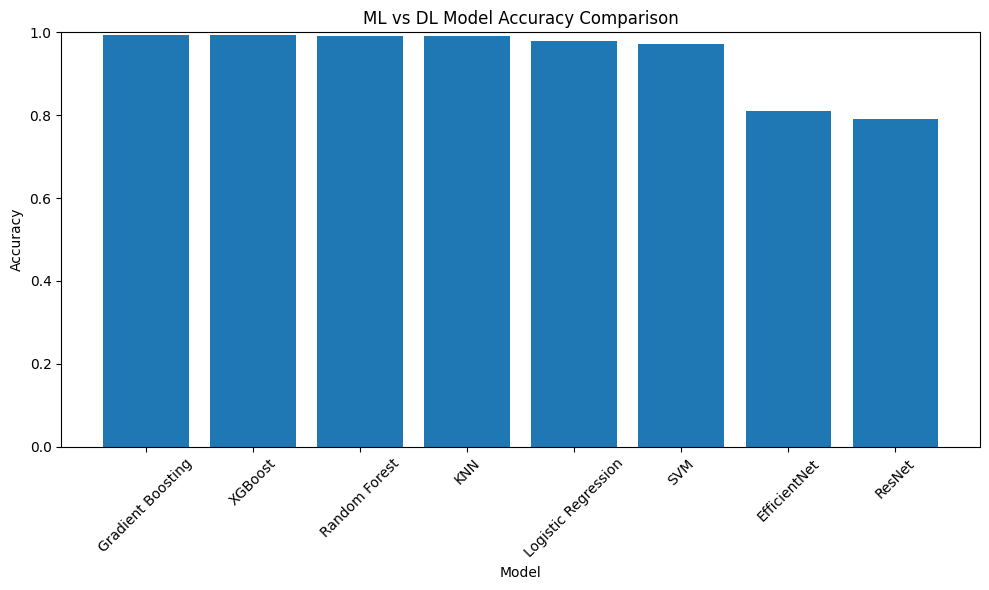

In [53]:
# ==========================================
# ACCURACY COMPARISON GRAPH
# ==========================================

plt.figure(figsize=(10,6))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])

plt.title("ML vs DL Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Best Model Identification

In [54]:
# ==========================================
# BEST MODEL IDENTIFICATION
# ==========================================

best_model = comparison_df.iloc[0]

print("="*50)
print("BEST PERFORMING MODEL")
print("="*50)

print("Model:", best_model["Model"])
print("Model Type:", best_model["Model Type"])
print("Accuracy:", best_model["Accuracy"])

if "ROC-AUC" in comparison_df.columns:
    print("ROC-AUC:", best_model["ROC-AUC"])

BEST PERFORMING MODEL
Model: Gradient Boosting
Model Type: Machine Learning
Accuracy: 0.9935275080906149
ROC-AUC: 0.9975273717847977
